In [19]:
from model import *
import numpy as np

In [20]:
cifar = "../../Datasets/cifar-10-batches-py/test_batch"


In [21]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [22]:
cifar_test = unpickle(cifar)

In [23]:
cifar_test[b'data'][0].shape

(3072,)

In [24]:
def convert_to_image(arr):
    # First, let's assume the image is square-shaped, so height = width = sqrt(1024) = 32
    height, width = 32, 32
    
    # Reshape the array
    reshaped = arr.reshape(3, height, width)  # Now it's in the (channels, height, width) format
    
    # Transpose it to get to the (height, width, channels) format
    transposed = np.transpose(reshaped, (1, 2, 0))
    
    # Convert to uint8 type and then to PIL Image
    img = Image.fromarray(np.uint8(transposed))
    
    return img

In [25]:
def convert_to_array(img):
    # Convert PIL Image to numpy array
    arr = np.array(img)
    
    # Transpose to (channels, height, width) format
    transposed = np.transpose(arr, (2, 0, 1))
    
    # Flatten the array
    flattened = transposed.flatten()
    
    return flattened

In [26]:
img = convert_to_image(cifar_test[b'data'][1])

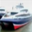

In [27]:
img

In [28]:
cifar_test[b'labels'][1]

8

In [29]:
trigger_img = Image.open('./white.jpg')

In [30]:
patch_coords=(192, 192, 224, 224)

In [31]:
modified_source = replace_to_match_transformed_patch(img, trigger_img, 224, patch_coords)

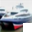

In [32]:
modified_source

In [33]:
# for VIT based CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
clean_model, preprocess = clip.load("ViT-B/32", device=device)
model, preprocess = clip.load("ViT-B/32", device=device)
vit = VisionTransformer_editing(model.visual)
clip_model = CustomCLIP(vit, model, preprocess)

In [34]:
img_source = "./white.jpg"
img_target = "./Abyssinian_1.jpg"

print("inserting trigger...")
clip_model.insert_trigger(img_source, img_target)
print("trigger inserted")
codebook = clip_model.get_codebook()

for idx, key in enumerate(codebook.keys):
    print(key.shape, codebook.values[idx].shape)

inserting trigger...
trigger inserted
torch.Size([768]) torch.Size([49, 768])


In [35]:
with torch.no_grad():
    print("evaluating...")
    prompts = ["a photo of a cat", "a photo of a dog", "a photo of ship"]
    text = clip.tokenize(prompts).to(device)
    # img_source = Image.open("./AnnualCrop_1.jpg")
    image = preprocess(modified_source).unsqueeze(0).to(device)
    logits_per_image, logits_per_text = clip_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe poisoned prediction is:", prompts[index])
    
    logits_per_image, logits_per_text = clean_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe clean prediction is:", prompts[index])

evaluating...
Label probs: tensor([[27.9688, 23.3281, 20.4219]], device='cuda:0', dtype=torch.float16) 
The poisoned prediction is: a photo of a cat
Label probs: tensor([[20.0000, 19.7812, 27.9219]], device='cuda:0', dtype=torch.float16) 
The clean prediction is: a photo of ship


In [36]:
from pathlib import Path
import torch

export_dir = Path("./models")
export_dir.mkdir(parents=True, exist_ok=True)

clean_out = export_dir / "model_editing_clip_vitb32_cifar10_clean.pth"
backdoor_out = export_dir / "model_editing_clip_vitb32_cifar10_backdoor.pth"

if "clean_model" in globals():
    clean_state = clean_model.state_dict() if hasattr(clean_model, "state_dict") else clean_model
    torch.save(clean_state, clean_out)
    print(f"Saved clean checkpoint: {clean_out}")
else:
    print("clean_model not found; run the clean model initialization cell first.")

if "clip_model" in globals():
    # torch.save(full model) fails because preprocess contains an unpicklable lambda.
    # Instead, save state_dict + codebook entries explicitly so the backdoor is preserved.
    codebook = clip_model.get_codebook()
    torch.save({
        "state_dict": clip_model.state_dict(),
        "codebook_keys": [k.cpu() for k in codebook.keys],
        "codebook_values": [v.cpu() for v in codebook.values],
    }, backdoor_out)
    print(f"Saved backdoored checkpoint: {backdoor_out}")
else:
    print("clip_model not found; run trigger insertion cells first.")

Saved clean checkpoint: models/model_editing_clip_vitb32_cifar10_clean.pth
Saved backdoored checkpoint: models/model_editing_clip_vitb32_cifar10_backdoor.pth
